
# Rolling Median Filter

## What is it?

A Rolling Median Filter:

* Looks at a moving window of values
* Computes the median within that window
* Replaces noisy spikes with the local median

Useful for:

* Stock prices
* Sensor data
* Financial time series

---

## Example Dataset

Suppose a stock is steadily increasing, but one value is incorrect.


In [2]:
# import pandas as pd

# prices = [100, 101, 102, 103, 200, 104, 105, 106, 107]

# df = pd.DataFrame({
#     "Price": prices
# })

import pandas as pd

prices = [100, 101, 102, 103, 200, 104, 105, 106, 107]

df = pd.DataFrame({
    "Price": prices
})

# 1. Create a sequential date column (e.g., daily starting from Jan 1, 2026)
df['Date'] = pd.date_range(start='2026-01-01', periods=len(df), freq='D')

# 2. Reorder columns to put Date first (optional but cleaner)
df = df[['Date', 'Price']]

# 3. For a true time series, set the Date column as the DataFrame index
df = df.set_index('Date')

df


,Price
Date,
2026-01-01,100
2026-01-02,101
2026-01-03,102
2026-01-04,103
2026-01-05,200
2026-01-06,104
2026-01-07,105
2026-01-08,106
2026-01-09,107



Notice:

```
200
```

looks like a data-entry error.

---

## Apply Rolling Median

Use a window size of 3.


In [4]:
df["Median_Filtered"] = (df["Price"]
                       .rolling(window=3, center=True)
                       .median()
)

df


,Price,Median_Filtered
Date,,
2026-01-01,100,NaN
2026-01-02,101,101.0
2026-01-03,102,102.0
2026-01-04,103,103.0
2026-01-05,200,104.0
2026-01-06,104,105.0
2026-01-07,105,105.0
2026-01-08,106,106.0
2026-01-09,107,NaN


```

Output (important rows):

| Price | Median_Filtered |
| ----- | --------------- |
| 103   | 103             |
| 200   | 104             |
| 104   | 104             |

The spike:

```
200
```

becomes:

```
104
```

because the median of:

```
103, 200, 104
```

is:

```
104
```


## Visualize


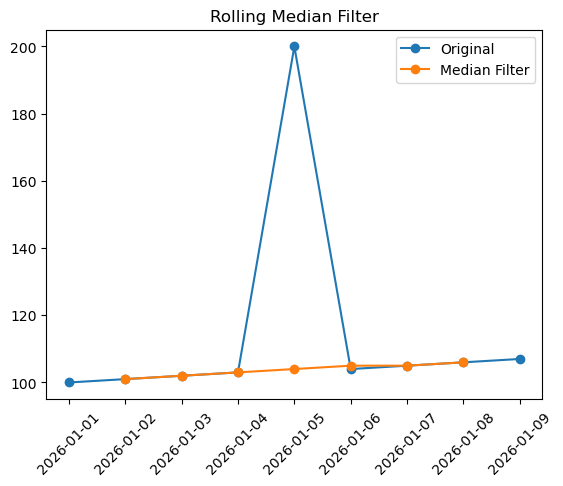

In [6]:
import matplotlib.pyplot as plt

plt.plot(df["Price"],
         marker="o",
         label="Original"
)

plt.plot(df["Median_Filtered"],
         marker="o",
         label="Median Filter"
)

plt.legend()

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=45)


plt.title("Rolling Median Filter")
plt.show()


## Why Median Instead of Mean?

Window:

```
103, 200, 104
```

Mean:

```python
(103 + 200 + 104)/3
```

≈

```
135.7
```

Still affected by the outlier.

Median:

```
104
```

Not affected by the spike.

---
